# EDA: Preprocessed Jira Dataset vs Cleaned Dataset

This notebook compares the dataset before cleaning (`Datasets/preprocessed_jira_data.csv`) and after cleaning (`artifacts/cleaned_dataset.csv`).

The goal is to understand how the cleaning step changes the training data used by the duration estimation model.

## 1. Setup

Load the required libraries and dataset paths.

In [22]:
from pathlib import Path

import pandas as pd
import numpy as np

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False
    print("matplotlib is not installed, so plot cells will print summaries instead.")

BASE_DIR = Path.cwd()
PREPROCESSED_PATH = BASE_DIR / "Datasets" / "preprocessed_jira_data.csv"
CLEANED_PATH = BASE_DIR / "artifacts" / "cleaned_dataset.csv"

PREPROCESSED_PATH, CLEANED_PATH

(WindowsPath('c:/Users/Jason/Desktop/RM_Latest/TaskSchedulerV2/TaskScheduler/Datasets/preprocessed_jira_data.csv'),
 WindowsPath('c:/Users/Jason/Desktop/RM_Latest/TaskSchedulerV2/TaskScheduler/artifacts/cleaned_dataset.csv'))

## 2. Load Datasets

- **Preprocessed dataset**: feature-engineered data before final training cleanup.
- **Cleaned dataset**: filtered data used for model training.

In [23]:
preprocessed_df = pd.read_csv(PREPROCESSED_PATH)
cleaned_df = pd.read_csv(CLEANED_PATH)

print("Preprocessed shape:", preprocessed_df.shape)
print("Cleaned shape:", cleaned_df.shape)

Preprocessed shape: (21645, 4)
Cleaned shape: (3016, 8)


In [24]:
display(preprocessed_df.head())
display(cleaned_df.head())

,expert_estimated_effort,actual_effort,complexity_class,task_type
0,0,1200,NaN,general
1,0,4800,NaN,coding
2,0,2400,NaN,reading
3,0,2400,NaN,coding
4,0,7800,NaN,reading


,expert_estimated_effort,actual_effort,complexity_class,task_type,effort_ratio,allowed_ratio,lower_ratio,upper_ratio
0,7200,9000,3,research,1.250000,3.0,0.333333,3.0
1,10800,14400,3,review,1.333333,2.0,0.500000,2.0
2,3600,7200,2,coding,2.000000,4.0,0.250000,4.0
3,3600,1800,2,research,0.500000,3.0,0.333333,3.0
4,7200,13200,3,research,1.833333,3.0,0.333333,3.0


## 3. Row Count Comparison

This shows how many rows were removed by the cleaning process.

In [25]:
row_summary = pd.DataFrame({
    "dataset": ["preprocessed", "cleaned"],
    "rows": [len(preprocessed_df), len(cleaned_df)],
    "columns": [preprocessed_df.shape[1], cleaned_df.shape[1]],
})

rows_removed = len(preprocessed_df) - len(cleaned_df)
percent_removed = rows_removed / len(preprocessed_df) * 100

display(row_summary)
print(f"Rows removed during cleaning: {rows_removed:,}")
print(f"Percentage removed: {percent_removed:.2f}%")

,dataset,rows,columns
0,preprocessed,21645,4
1,cleaned,3016,8


Rows removed during cleaning: 18,629
Percentage removed: 86.07%


## 4. Missing Values

Check whether cleaning removed or reduced missing values.

In [26]:
missing_summary = pd.DataFrame({
    "preprocessed_missing": preprocessed_df.isna().sum(),
    "cleaned_missing": cleaned_df.isna().sum(),
})

display(missing_summary)

,preprocessed_missing,cleaned_missing
actual_effort,0.0,0
allowed_ratio,NaN,0
complexity_class,17351.0,0
effort_ratio,NaN,0
expert_estimated_effort,0.0,0
lower_ratio,NaN,0
task_type,0.0,0
upper_ratio,NaN,0


## 5. Invalid Effort Values

The cleaned dataset removes rows where `expert_estimated_effort <= 0` or `actual_effort <= 0`.

In [27]:
def invalid_effort_summary(df, name):
    return {
        "dataset": name,
        "rows": len(df),
        "expert_estimated_effort <= 0": int((df["expert_estimated_effort"] <= 0).sum()),
        "actual_effort <= 0": int((df["actual_effort"] <= 0).sum()), "actual effort > 360000": int((df["actual_effort"] > 360000).sum()),
    }

invalid_summary = pd.DataFrame([
    invalid_effort_summary(preprocessed_df, "preprocessed"),
    invalid_effort_summary(cleaned_df, "cleaned"),
])

display(invalid_summary)

,dataset,rows,expert_estimated_effort <= 0,actual_effort <= 0,actual effort > 360000
0,preprocessed,21645,17351,1,80
1,cleaned,3016,0,0,0


## 6. Descriptive Statistics

Compare the core numeric columns before and after cleaning.

In [28]:
numeric_columns = ["expert_estimated_effort", "actual_effort", "complexity_class"]

print("Preprocessed dataset statistics")
display(preprocessed_df[numeric_columns].describe().T)

print("Cleaned dataset statistics")
display(cleaned_df[numeric_columns].describe().T)

Preprocessed dataset statistics


,count,mean,std,min,25%,50%,75%,max
expert_estimated_effort,21645.0,10067.406791,90591.934829,0.0,0.0,0.0,0.0,10368000.0
actual_effort,21645.0,16694.444075,71373.316367,0.0,1800.0,3600.0,11400.0,5184000.0
complexity_class,4294.0,3.774802,1.280690,1.0,3.0,4.0,5.0,5.0


Cleaned dataset statistics


,count,mean,std,min,25%,50%,75%,max
expert_estimated_effort,3016.0,19818.103448,22930.505665,300.0,3600.0,14400.0,28800.0,259200.0
actual_effort,3016.0,17710.036472,18319.310841,180.0,3600.0,10800.0,28800.0,84600.0
complexity_class,3016.0,3.524204,1.267561,1.0,2.0,4.0,5.0,5.0


## 7. Effort Ratio Analysis

The cleaning process uses `actual_effort / expert_estimated_effort` to remove rows where the actual time is unrealistically different from the expert estimate.

In [29]:
preprocessed_ratio_df = preprocessed_df[
    (preprocessed_df["expert_estimated_effort"] > 0) &
    (preprocessed_df["actual_effort"] > 0)
].copy()
preprocessed_ratio_df["effort_ratio"] = (
    preprocessed_ratio_df["actual_effort"] / preprocessed_ratio_df["expert_estimated_effort"]
)

ratio_summary = pd.DataFrame({
    "preprocessed_ratio": preprocessed_ratio_df["effort_ratio"].describe(),
    "cleaned_ratio": cleaned_df["effort_ratio"].describe() if "effort_ratio" in cleaned_df.columns else np.nan,
})

display(ratio_summary)

,preprocessed_ratio,cleaned_ratio
count,4294.000000,3016.000000
mean,1.307439,1.007942
std,7.849697,0.466825
min,0.001089,0.250000
25%,0.500000,0.750000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,480.000000,4.000000


## 8. Task Type Distribution

Compare whether cleaning changes the balance of task categories.

In [30]:
task_type_summary = pd.DataFrame({
    "preprocessed_count": preprocessed_df["task_type"].value_counts(),
    "cleaned_count": cleaned_df["task_type"].value_counts(),
}).fillna(0).astype(int)

task_type_summary["preprocessed_percent"] = task_type_summary["preprocessed_count"] / len(preprocessed_df) * 100
task_type_summary["cleaned_percent"] = task_type_summary["cleaned_count"] / len(cleaned_df) * 100

display(task_type_summary.sort_values("preprocessed_count", ascending=False))

,preprocessed_count,cleaned_count,preprocessed_percent,cleaned_percent
task_type,,,,
general,9288,1239,42.910603,41.080902
coding,7746,1063,35.786556,35.245358
writing,1577,253,7.285747,8.388594
reading,1435,205,6.629707,6.797082
review,803,149,3.709864,4.940318
research,425,63,1.963502,2.088859
problem solving,371,44,1.714022,1.458886


## 9. Complexity Class Distribution

Compare the complexity classes before and after cleaning.

In [31]:
complexity_summary = pd.DataFrame({
    "preprocessed_count": preprocessed_df["complexity_class"].value_counts(dropna=False).sort_index(),
    "cleaned_count": cleaned_df["complexity_class"].value_counts(dropna=False).sort_index(),
}).fillna(0).astype(int)

display(complexity_summary)

,preprocessed_count,cleaned_count
complexity_class,,
1.0,141,110
2.0,821,714
3.0,804,679
4.0,626,511
5.0,1902,1002
NaN,17351,0


## 10. Distribution Plots

These plots show how cleaning changes the numeric feature distributions.

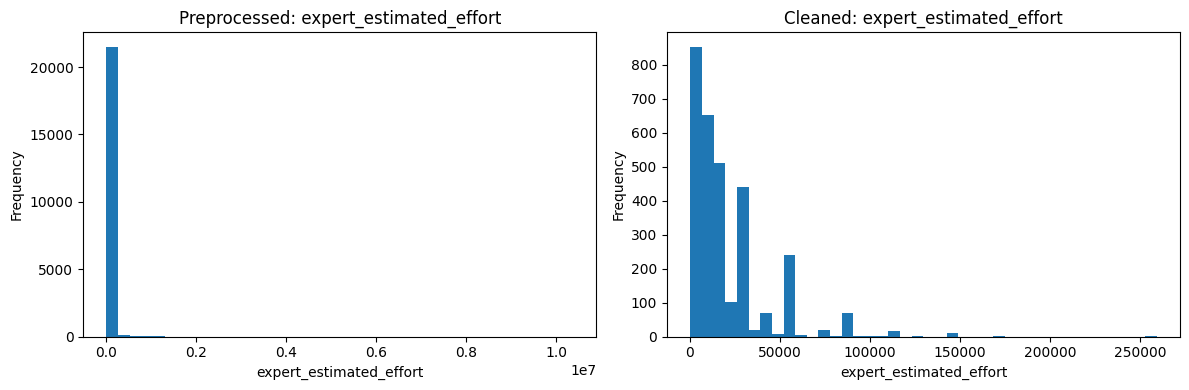

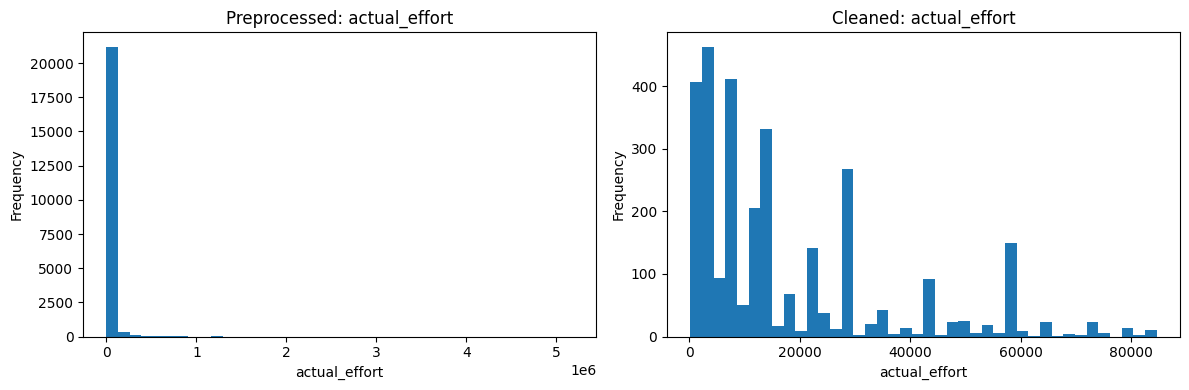

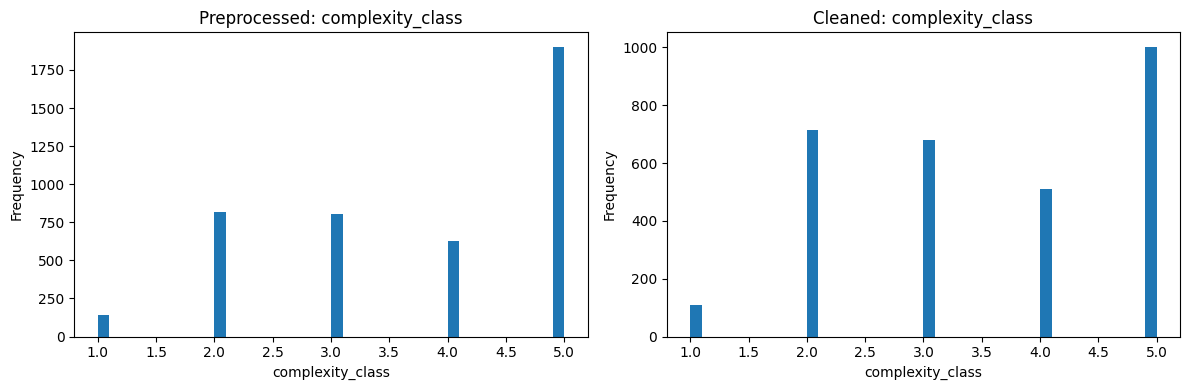

In [32]:
def compare_histograms(column, bins=40):
    if not HAS_MATPLOTLIB:
        print(f"Skipping plot for {column}: matplotlib is not installed.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    preprocessed_df[column].dropna().plot(kind="hist", bins=bins, ax=axes[0], title=f"Preprocessed: {column}")
    cleaned_df[column].dropna().plot(kind="hist", bins=bins, ax=axes[1], title=f"Cleaned: {column}")

    axes[0].set_xlabel(column)
    axes[1].set_xlabel(column)
    plt.tight_layout()
    plt.show()

for column in ["expert_estimated_effort", "actual_effort", "complexity_class"]:
    compare_histograms(column)

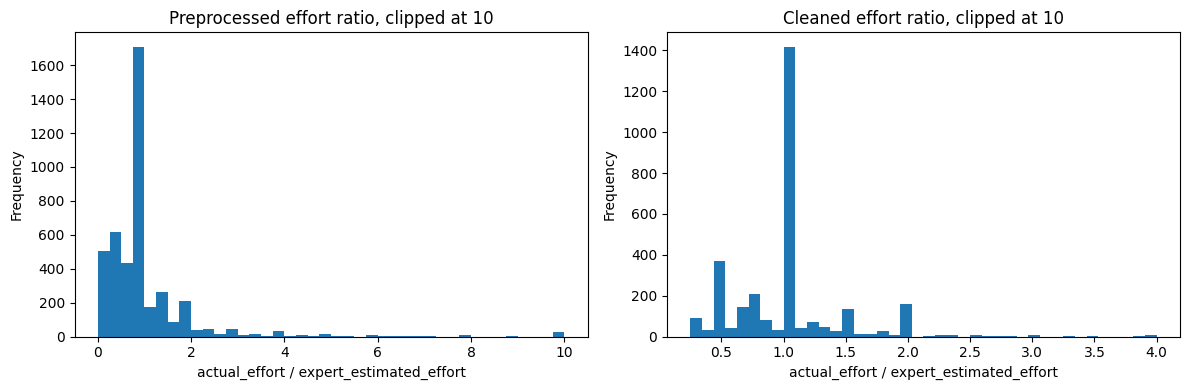

In [33]:
if HAS_MATPLOTLIB:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    preprocessed_ratio_df["effort_ratio"].clip(upper=10).plot(
        kind="hist", bins=40, ax=axes[0], title="Preprocessed effort ratio, clipped at 10"
    )
    cleaned_df["effort_ratio"].clip(upper=10).plot(
        kind="hist", bins=40, ax=axes[1], title="Cleaned effort ratio, clipped at 10"
    )
    axes[0].set_xlabel("actual_effort / expert_estimated_effort")
    axes[1].set_xlabel("actual_effort / expert_estimated_effort")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping effort ratio plot: matplotlib is not installed.")

## 11. Relationship Between Model Features and Target

The model predicts `actual_effort` using `expert_estimated_effort`, `complexity_class`, and encoded `task_type`.

In [34]:
print("Preprocessed correlation")
display(preprocessed_df[numeric_columns].corr(numeric_only=True))

print("Cleaned correlation")
display(cleaned_df[numeric_columns].corr(numeric_only=True))

Preprocessed correlation


,expert_estimated_effort,actual_effort,complexity_class
expert_estimated_effort,1.000000,0.595496,0.217657
actual_effort,0.595496,1.000000,0.261525
complexity_class,0.217657,0.261525,1.000000


Cleaned correlation


,expert_estimated_effort,actual_effort,complexity_class
expert_estimated_effort,1.000000,0.830260,0.722004
actual_effort,0.830260,1.000000,0.753562
complexity_class,0.722004,0.753562,1.000000


In [35]:
task_type_effort_summary = cleaned_df.groupby("task_type").agg(
    rows=("actual_effort", "size"),
    mean_actual_effort=("actual_effort", "mean"),
    median_actual_effort=("actual_effort", "median"),
    mean_expert_estimated_effort=("expert_estimated_effort", "mean"),
).sort_values("rows", ascending=False)

display(task_type_effort_summary)

,rows,mean_actual_effort,median_actual_effort,mean_expert_estimated_effort
task_type,,,,
general,1239,16080.847458,9000.0,17314.527845
coding,1063,18530.460960,10800.0,21989.463782
writing,253,20606.324111,12600.0,21560.869565
reading,205,18140.487805,10800.0,19981.463415
review,149,20171.677852,14400.0,21825.503356
research,63,21965.714286,13200.0,27157.142857
problem solving,44,10677.272727,6750.0,9770.454545


## 12. EDA Conclusion

Use this section to summarize your findings after running the notebook.

Suggested points to discuss:

- How many rows were removed by cleaning.
- Whether invalid `expert_estimated_effort` values were removed.
- Whether the cleaned dataset has fewer extreme `actual_effort` values.
- Whether task type and complexity distributions changed after cleaning.
- Why the cleaned dataset is more appropriate for training the duration model.

In [36]:
print("Final summary")
print(f"Preprocessed rows: {len(preprocessed_df):,}")
print(f"Cleaned rows: {len(cleaned_df):,}")
print(f"Rows removed: {rows_removed:,} ({percent_removed:.2f}%)")
print(f"Preprocessed actual_effort median: {preprocessed_df['actual_effort'].median():,.2f}")
print(f"Cleaned actual_effort median: {cleaned_df['actual_effort'].median():,.2f}")
print(f"Preprocessed expert_estimated_effort median: {preprocessed_df['expert_estimated_effort'].median():,.2f}")
print(f"Cleaned expert_estimated_effort median: {cleaned_df['expert_estimated_effort'].median():,.2f}")

Final summary
Preprocessed rows: 21,645
Cleaned rows: 3,016
Rows removed: 18,629 (86.07%)
Preprocessed actual_effort median: 3,600.00
Cleaned actual_effort median: 10,800.00
Preprocessed expert_estimated_effort median: 0.00
Cleaned expert_estimated_effort median: 14,400.00


## 13. Noise Analysis

This section quantifies the amount of "noise" (outliers and extreme values) in the datasets.


In [37]:
def count_outliers_iqr(df, column):
    """Count outliers using IQR method (values outside Q1-1.5*IQR, Q3+1.5*IQR)"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[column] < Q1 - 1.5*IQR) | (df[column] > Q3 + 1.5*IQR)).sum()
    return outliers, (outliers/len(df)*100) if len(df) > 0 else 0

print("=" * 60)
print("OUTLIER DETECTION (IQR Method)")
print("=" * 60)

outlier_data = []
for col in ["expert_estimated_effort", "actual_effort"]:
    if col in preprocessed_df.columns:
        pre_outliers, pre_pct = count_outliers_iqr(preprocessed_df, col)
        clean_outliers, clean_pct = count_outliers_iqr(cleaned_df, col)
        outlier_data.append({
            "column": col,
            "preprocessed_outliers": pre_outliers,
            "preprocessed_percent": f"{pre_pct:.2f}%",
            "cleaned_outliers": clean_outliers,
            "cleaned_percent": f"{clean_pct:.2f}%"
        })

outlier_df = pd.DataFrame(outlier_data)
display(outlier_df)


OUTLIER DETECTION (IQR Method)


,column,preprocessed_outliers,preprocessed_percent,cleaned_outliers,cleaned_percent
0,expert_estimated_effort,4294,19.84%,121,4.01%
1,actual_effort,2818,13.02%,62,2.06%


In [38]:
print("\n" + "=" * 60)
print("EXTREME VALUE ANALYSIS")
print("=" * 60)

noise_metrics = pd.DataFrame({
    "metric": [
        "actual_effort > 360000 (extreme high)",
        "expert_estimated_effort > 18000 (extreme high)",
        "effort_ratio > 5 (unrealistic multiplier)",
        "effort_ratio < 0.2 (unrealistic underestimate)",
        "effort_ratio between 0.2 and 5 (reasonable)"
    ],
    "preprocessed_count": [
        (preprocessed_df["actual_effort"] > 360000).sum(),
        (preprocessed_df["expert_estimated_effort"] > 18000).sum(),
        (preprocessed_ratio_df["effort_ratio"] > 5).sum() if "effort_ratio" in preprocessed_ratio_df.columns else 0,
        (preprocessed_ratio_df["effort_ratio"] < 0.2).sum() if "effort_ratio" in preprocessed_ratio_df.columns else 0,
        ((preprocessed_ratio_df["effort_ratio"] >= 0.2) & (preprocessed_ratio_df["effort_ratio"] <= 5)).sum() if "effort_ratio" in preprocessed_ratio_df.columns else 0,
    ],
    "cleaned_count": [
        (cleaned_df["actual_effort"] > 360000).sum(),
        (cleaned_df["expert_estimated_effort"] > 18000).sum(),
        (cleaned_df["effort_ratio"] > 5).sum() if "effort_ratio" in cleaned_df.columns else 0,
        (cleaned_df["effort_ratio"] < 0.2).sum() if "effort_ratio" in cleaned_df.columns else 0,
        ((cleaned_df["effort_ratio"] >= 0.2) & (cleaned_df["effort_ratio"] <= 5)).sum() if "effort_ratio" in cleaned_df.columns else 0,
    ]
})

noise_metrics["preprocessed_percent"] = (noise_metrics["preprocessed_count"] / len(preprocessed_df) * 100).round(2)
noise_metrics["cleaned_percent"] = (noise_metrics["cleaned_count"] / len(cleaned_df) * 100).round(2)

display(noise_metrics)



EXTREME VALUE ANALYSIS


,metric,preprocessed_count,cleaned_count,preprocessed_percent,cleaned_percent
0,actual_effort > 360000 (extreme high),80,0,0.37,0.00
1,expert_estimated_effort > 18000 (extreme high),1902,1002,8.79,33.22
2,effort_ratio > 5 (unrealistic multiplier),67,0,0.31,0.00
3,effort_ratio < 0.2 (unrealistic underestimate),333,0,1.54,0.00
4,effort_ratio between 0.2 and 5 (reasonable),3894,3016,17.99,100.00


In [39]:
print("\n" + "=" * 60)
print("NOISE REDUCTION SUMMARY")
print("=" * 60)

if "effort_ratio" in preprocessed_ratio_df.columns and "effort_ratio" in cleaned_df.columns:
    pre_noisy = ((preprocessed_ratio_df["effort_ratio"] < 0.2) | (preprocessed_ratio_df["effort_ratio"] > 5)).sum()
    clean_noisy = ((cleaned_df["effort_ratio"] < 0.2) | (cleaned_df["effort_ratio"] > 5)).sum()
    
    pre_noisy_pct = pre_noisy / len(preprocessed_ratio_df) * 100
    clean_noisy_pct = clean_noisy / len(cleaned_df) * 100
    
    print(f"Preprocessed: {pre_noisy:,} noisy records ({pre_noisy_pct:.2f}%)")
    print(f"Cleaned: {clean_noisy:,} noisy records ({clean_noisy_pct:.2f}%)")
    print(f"Noise reduced by: {pre_noisy - clean_noisy:,} records ({((pre_noisy - clean_noisy)/pre_noisy*100):.2f}%)")



NOISE REDUCTION SUMMARY
Preprocessed: 400 noisy records (9.32%)
Cleaned: 0 noisy records (0.00%)
Noise reduced by: 400 records (100.00%)


## 14. Noise Visualization

Visual comparison of noise levels before and after cleaning.


C:\Users\Jason\AppData\Local\Temp\ipykernel_28484\3692863554.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([preprocessed_df["expert_estimated_effort"].dropna()], labels=["Preprocessed"])
C:\Users\Jason\AppData\Local\Temp\ipykernel_28484\3692863554.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([cleaned_df["expert_estimated_effort"].dropna()], labels=["Cleaned"])
C:\Users\Jason\AppData\Local\Temp\ipykernel_28484\3692863554.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([preprocessed_df["actual_effort"].dropna()], labels=["Preprocessed"])
C:\User

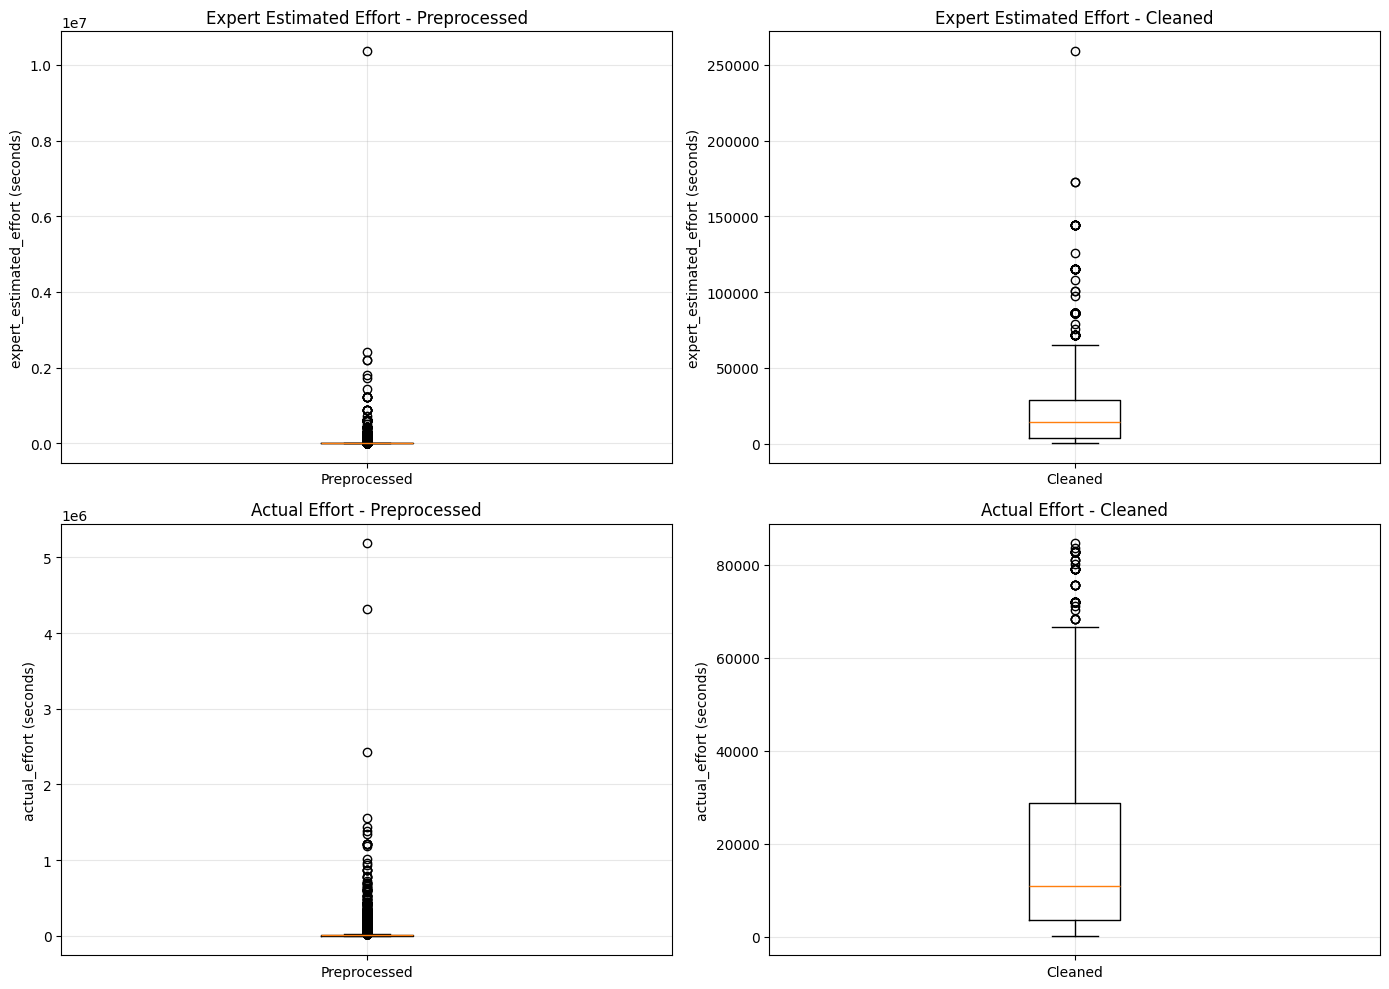

In [44]:
if HAS_MATPLOTLIB:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Expert Estimated Effort - Preprocessed
    axes[0, 0].boxplot([preprocessed_df["expert_estimated_effort"].dropna()], labels=["Preprocessed"])
    axes[0, 0].set_ylabel("expert_estimated_effort (seconds)")
    axes[0, 0].set_title("Expert Estimated Effort - Preprocessed")
    axes[0, 0].grid(True, alpha=0.3)
    
    # Expert Estimated Effort - Cleaned
    axes[0, 1].boxplot([cleaned_df["expert_estimated_effort"].dropna()], labels=["Cleaned"])
    axes[0, 1].set_ylabel("expert_estimated_effort (seconds)")
    axes[0, 1].set_title("Expert Estimated Effort - Cleaned")
    axes[0, 1].grid(True, alpha=0.3)
    
    # Actual Effort - Preprocessed
    axes[1, 0].boxplot([preprocessed_df["actual_effort"].dropna()], labels=["Preprocessed"])
    axes[1, 0].set_ylabel("actual_effort (seconds)")
    axes[1, 0].set_title("Actual Effort - Preprocessed")
    axes[1, 0].grid(True, alpha=0.3)
    
    # Actual Effort - Cleaned
    axes[1, 1].boxplot([cleaned_df["actual_effort"].dropna()], labels=["Cleaned"])
    axes[1, 1].set_ylabel("actual_effort (seconds)")
    axes[1, 1].set_title("Actual Effort - Cleaned")
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping plots: matplotlib is not installed.")

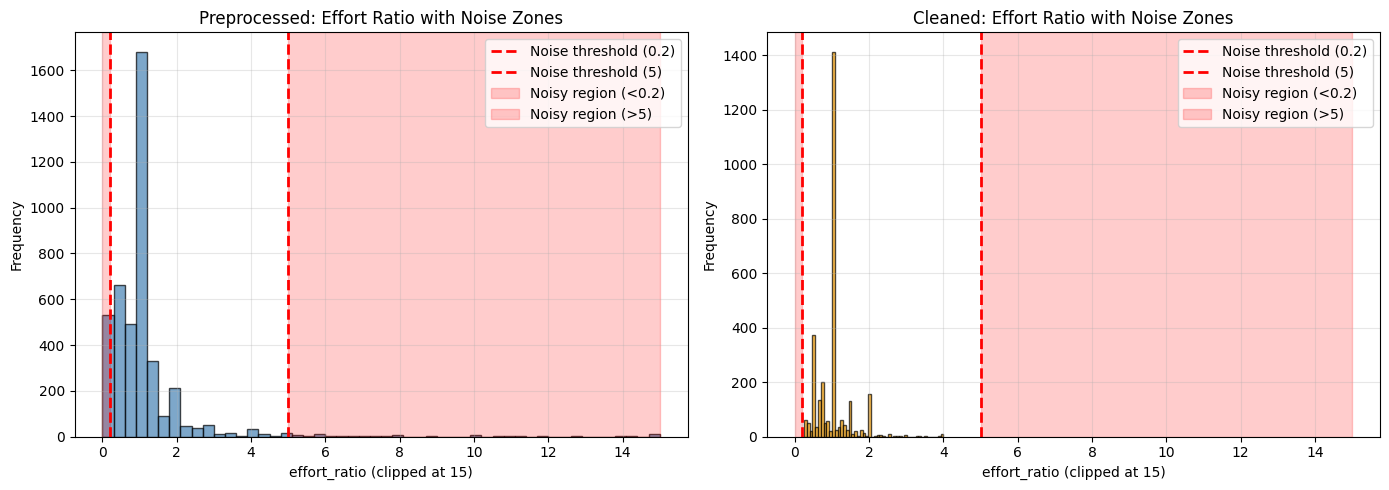

In [ ]:
if HAS_MATPLOTLIB and "effort_ratio" in cleaned_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Preprocessed effort ratio with noise zones
    axes[0].hist(preprocessed_ratio_df["effort_ratio"].clip(0, 15), bins=50, alpha=0.7, color="steelblue", edgecolor="black")
    axes[0].axvline(x=0.2, color='r', linestyle='--', linewidth=2, label='Noise threshold (0.2)')
    axes[0].axvline(x=5, color='r', linestyle='--', linewidth=2, label='Noise threshold (5)')
    axes[0].axvspan(0, 0.2, alpha=0.2, color='red', label='Noisy region (<0.2)')
    axes[0].axvspan(5, 15, alpha=0.2, color='red', label='Noisy region (>5)')
    axes[0].set_xlabel("effort_ratio (clipped at 15)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Preprocessed: Effort Ratio with Noise Zones")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Cleaned effort ratio with noise zones
    axes[1].hist(cleaned_df["effort_ratio"].clip(0, 15), bins=50, alpha=0.7, color="orange", edgecolor="black")
    axes[1].axvline(x=0.2, color='r', linestyle='--', linewidth=2, label='Noise threshold (0.2)')
    axes[1].axvline(x=5, color='r', linestyle='--', linewidth=2, label='Noise threshold (5)')
    axes[1].axvspan(0, 0.2, alpha=0.2, color='red', label='Noisy region (<0.2)')
    axes[1].axvspan(5, 15, alpha=0.2, color='red', label='Noisy region (>5)')
    axes[1].set_xlabel("effort_ratio (clipped at 15)")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title("Cleaned: Effort Ratio with Noise Zones")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping effort ratio comparison plot: matplotlib is not installed or effort_ratio not available.")


C:\Users\Jason\AppData\Local\Temp\ipykernel_28484\1766455914.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([cleaned_df["effort_ratio"].clip(0, 15)], labels=["Cleaned Dataset"], patch_artist=True)


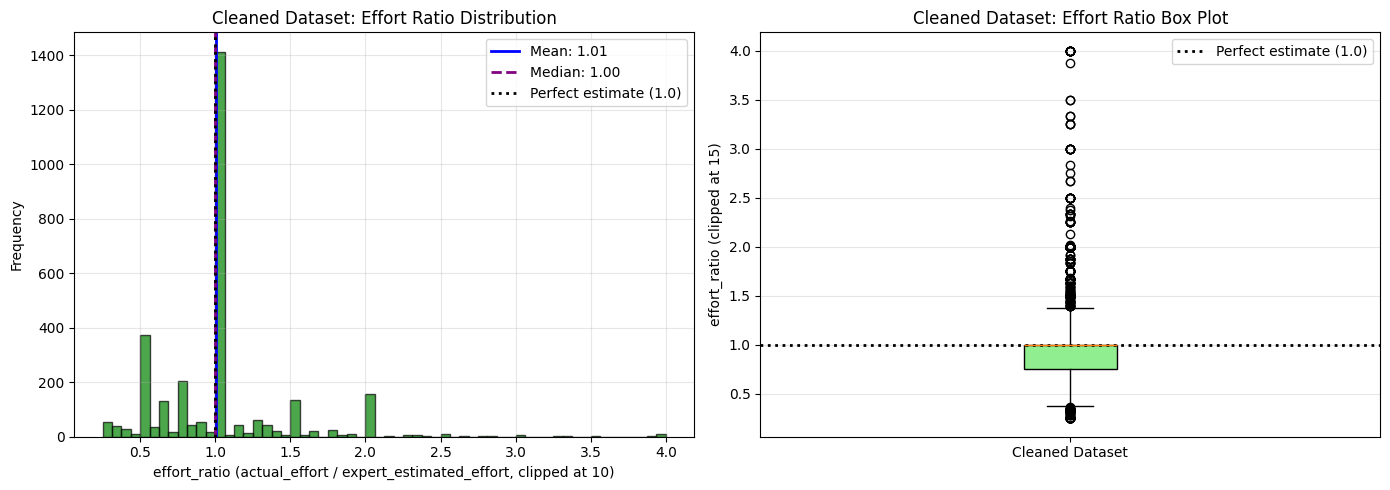


Cleaned Dataset - Effort Ratio Summary:
Mean: 1.0079
Median: 1.0000
Std Dev: 0.4668
Min: 0.2500
Max: 4.0000
Q1 (25th percentile): 0.7500
Q3 (75th percentile): 1.0000


In [45]:
if HAS_MATPLOTLIB and "effort_ratio" in cleaned_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram of effort ratio in cleaned dataset
    axes[0].hist(cleaned_df["effort_ratio"].clip(0, 10), bins=60, alpha=0.7, color="green", edgecolor="black")
    axes[0].axvline(x=cleaned_df["effort_ratio"].mean(), color='blue', linestyle='-', linewidth=2, label=f'Mean: {cleaned_df["effort_ratio"].mean():.2f}')
    axes[0].axvline(x=cleaned_df["effort_ratio"].median(), color='purple', linestyle='--', linewidth=2, label=f'Median: {cleaned_df["effort_ratio"].median():.2f}')
    axes[0].axvline(x=1, color='black', linestyle=':', linewidth=2, label='Perfect estimate (1.0)')
    axes[0].set_xlabel("effort_ratio (actual_effort / expert_estimated_effort, clipped at 10)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Cleaned Dataset: Effort Ratio Distribution")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Box plot of effort ratio in cleaned dataset
    bp = axes[1].boxplot([cleaned_df["effort_ratio"].clip(0, 15)], labels=["Cleaned Dataset"], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightgreen')
    axes[1].axhline(y=1, color='black', linestyle=':', linewidth=2, label='Perfect estimate (1.0)')
    axes[1].set_ylabel("effort_ratio (clipped at 15)")
    axes[1].set_title("Cleaned Dataset: Effort Ratio Box Plot")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nCleaned Dataset - Effort Ratio Summary:")
    print(f"Mean: {cleaned_df['effort_ratio'].mean():.4f}")
    print(f"Median: {cleaned_df['effort_ratio'].median():.4f}")
    print(f"Std Dev: {cleaned_df['effort_ratio'].std():.4f}")
    print(f"Min: {cleaned_df['effort_ratio'].min():.4f}")
    print(f"Max: {cleaned_df['effort_ratio'].max():.4f}")
    print(f"Q1 (25th percentile): {cleaned_df['effort_ratio'].quantile(0.25):.4f}")
    print(f"Q3 (75th percentile): {cleaned_df['effort_ratio'].quantile(0.75):.4f}")
else:
    print("Skipping cleaned dataset effort ratio plot: matplotlib is not installed or effort_ratio not available.")